In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [6]:
df  = pd.read_csv("loan_approval_data.csv")

In [7]:
df.head()
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [8]:
#handling missing data
categorical_cols = df.select_dtypes(include = ["object"]).columns
numerical_cols = df.select_dtypes(include=["float64","int64"]).columns

In [9]:
categorical_cols.size + numerical_cols.size

20

In [10]:
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [11]:
from sklearn.impute import SimpleImputer
num_imp = SimpleImputer (strategy = "mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

In [12]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [13]:
cat_imp = SimpleImputer (strategy = "most_frequent")
df[numerical_cols] = cat_imp.fit_transform(df[numerical_cols])

In [14]:
df.head()
df.isnull().sum()

Applicant_ID           0
Applicant_Income       0
Coapplicant_Income     0
Employment_Status     50
Age                    0
Marital_Status        50
Dependents             0
Credit_Score           0
Existing_Loans         0
DTI_Ratio              0
Savings                0
Collateral_Value       0
Loan_Amount            0
Loan_Term              0
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

EDA - Exploratory data analysis



Text(0.5, 1.0, 'Is Loan approved or not?')

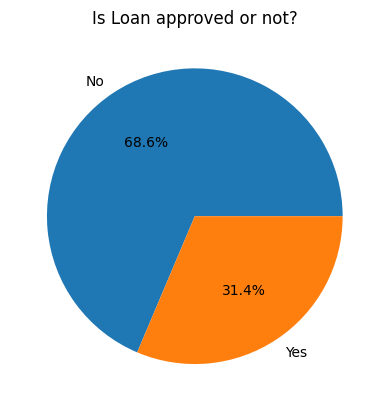

In [15]:
#how balanced our classes are?

classes_count = df["Loan_Approved"].value_counts()

plt.pie(classes_count.values, labels= ["No","Yes"], autopct = "%1.1f%%")
plt.title("Is Loan approved or not?")

[Text(0, 0, '672'), Text(0, 0, '278')]

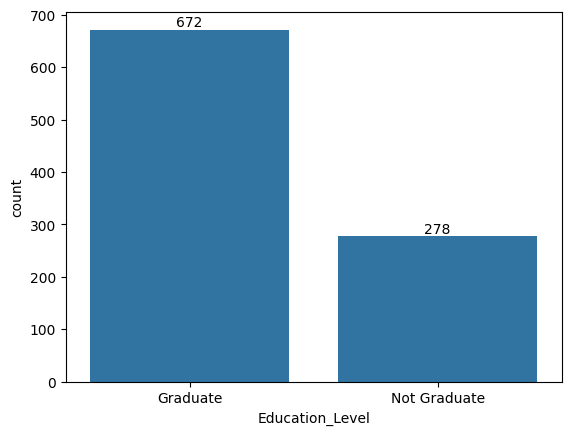

In [16]:
# analyze categories
#gender_cnt = df["Gender"].value_counts()
#sns.barplot(gender_cnt)
#ax.bar_label(ax.containers[0])

edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

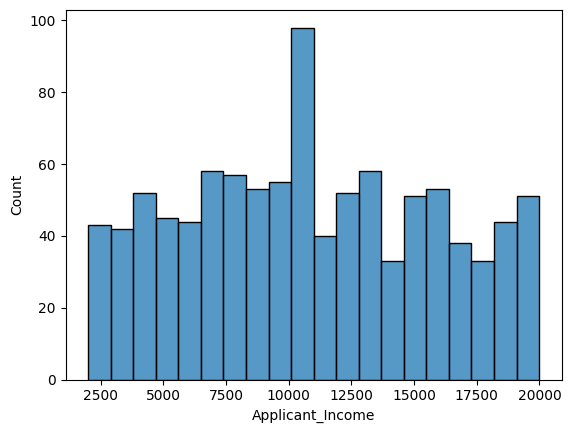

In [17]:
# analyze income
sns.histplot(
    data  = df,
    x= "Applicant_Income",
    bins = 20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

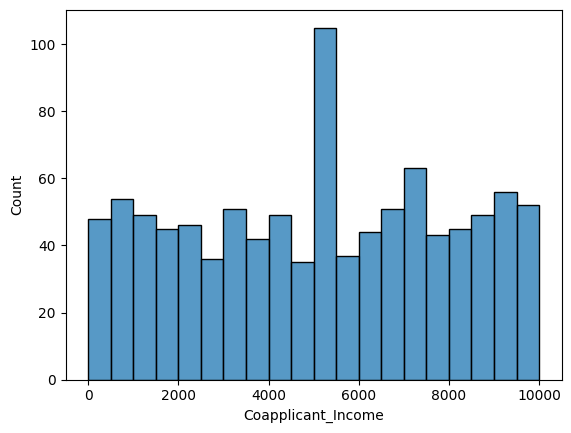

In [18]:
sns.histplot(
    data  = df,
    x= "Coapplicant_Income",
    bins = 20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

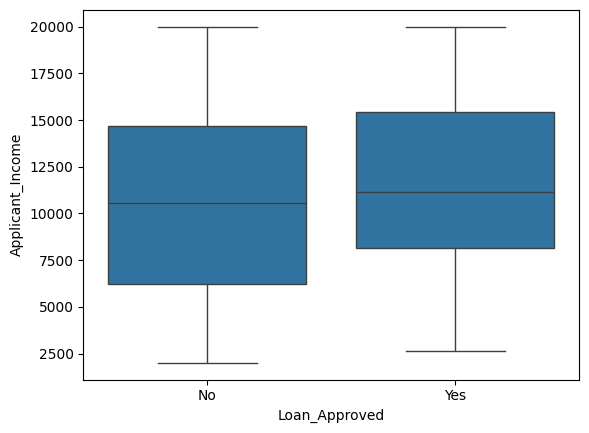

In [19]:
# outliers - boxplot
sns.boxplot(
    data = df,
    x="Loan_Approved",
    y = "Applicant_Income"
)

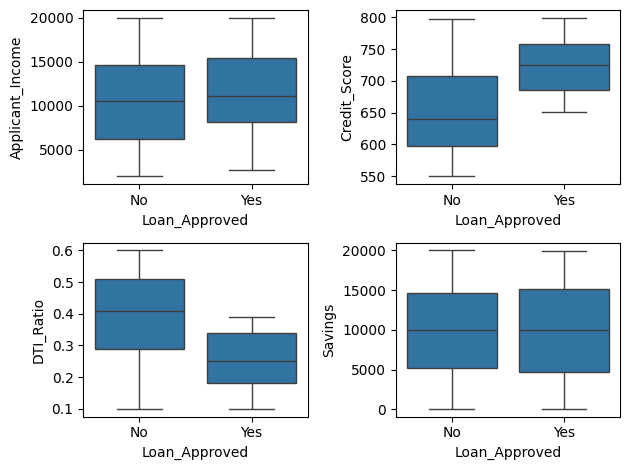

In [20]:
fig,axes = plt.subplots(2,2)

sns.boxplot(ax=axes[0,0], data = df, x="Loan_Approved",y = "Applicant_Income")
sns.boxplot(ax=axes[0,1], data = df, x="Loan_Approved",y = "Credit_Score")
sns.boxplot(ax=axes[1,0], data = df, x="Loan_Approved",y = "DTI_Ratio")
sns.boxplot(ax=axes[1,1], data = df, x="Loan_Approved",y = "Savings")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

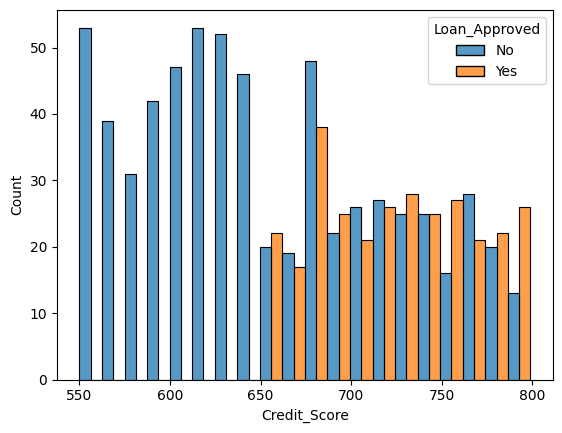

In [21]:
#credit score with loan approved
sns.histplot(
    data  = df,
    x= "Credit_Score",
    hue = "Loan_Approved",
    bins = 20,
    multiple = "dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

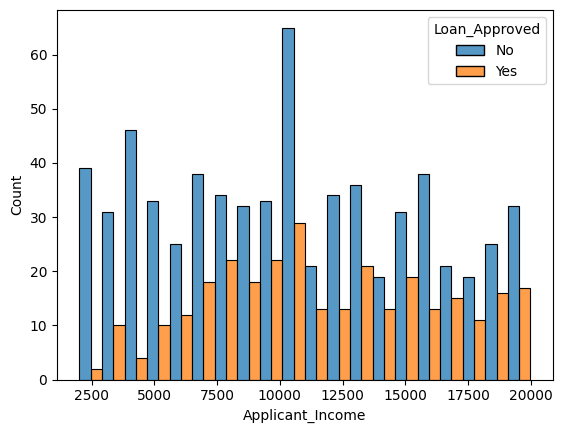

In [22]:
sns.histplot(
    data  = df,
    x= "Applicant_Income",
    hue = "Loan_Approved",
    bins = 20,
    multiple = "dodge"
)

In [23]:
# Remove applicant ID
df = df.drop("Applicant_ID",axis = 1)

In [24]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,NaN,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


Encoding


In [25]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

le=LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

cols = ["Employement_Status","Marital_Status","Loan_Purpose","Property_Area","Gender"," Employer_Category"]

In [26]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,NaN,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,2,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,0,Male,Private,1


In [27]:
cols = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]

one = OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")

encoded = one.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded, columns = one.get_feature_names_out(cols),index = df.index)

df = pd.concat([df.drop(columns = cols) , encoded_df ], axis = 1)

In [28]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

coorelation heatmap

<Axes: >

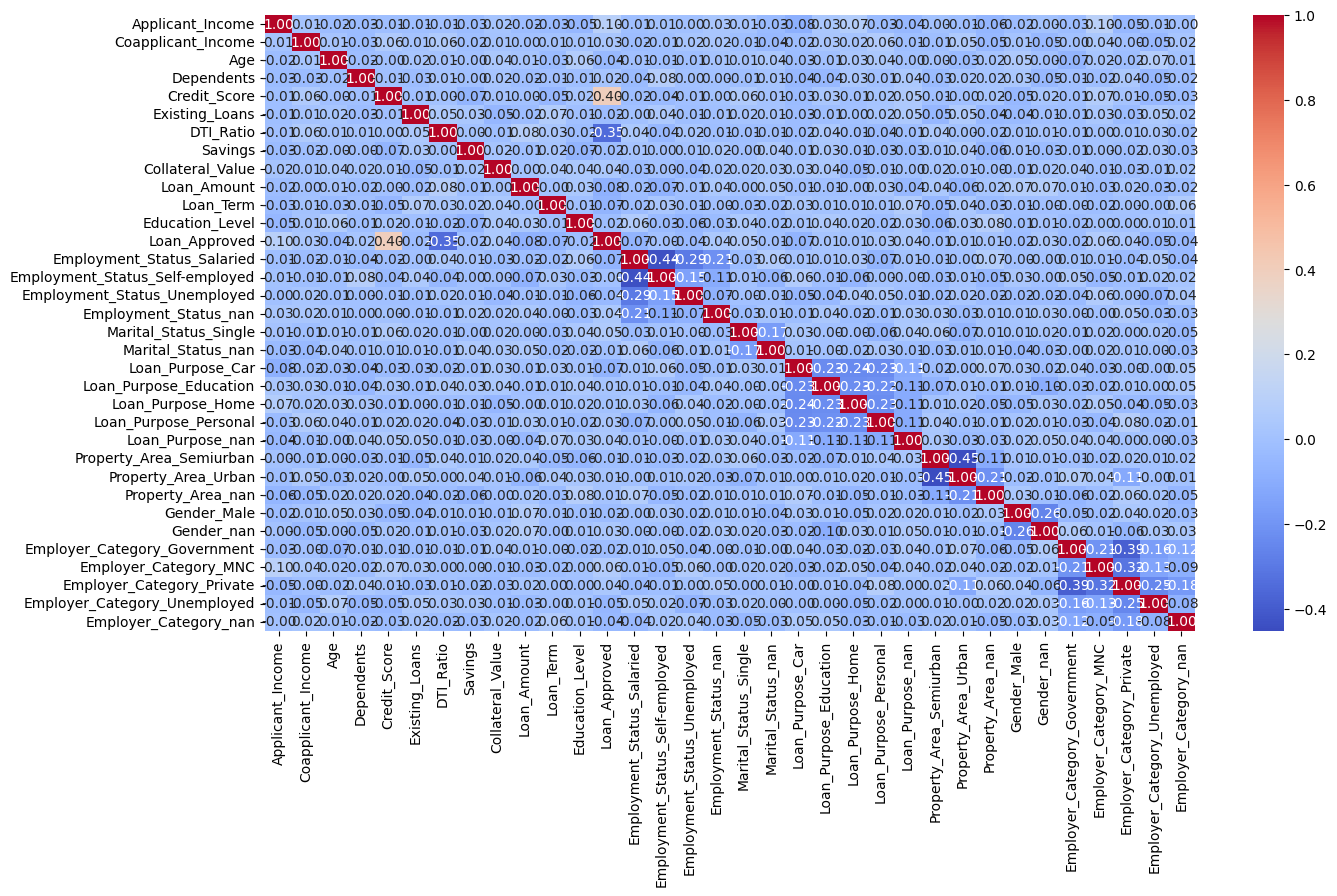

In [29]:
nums_cols = df.select_dtypes(include="number")
corr_matrix = nums_cols.corr()

plt.figure(figsize=(15,8))
sns.heatmap (
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

In [30]:
nums_cols.corr()["Loan_Approved"].sort_values(ascending = False)

Loan_Approved                      1.000000
Credit_Score                       0.395165
Applicant_Income                   0.097512
Employer_Category_MNC              0.062015
Marital_Status_Single              0.053416
Employment_Status_nan              0.040155
Loan_Purpose_nan                   0.040155
Collateral_Value                   0.039493
Employer_Category_Private          0.035304
Gender_nan                         0.032282
Loan_Purpose_Personal              0.027617
Coapplicant_Income                 0.025830
Dependents                         0.021759
Loan_Purpose_Education             0.013201
Property_Area_Urban                0.010779
Property_Area_nan                  0.008661
Loan_Purpose_Home                  0.006036
Employment_Status_Self-employed   -0.001939
Marital_Status_nan                -0.007086
Property_Area_Semiurban           -0.014122
Education_Level                   -0.019102
Gender_Male                       -0.021697
Employer_Category_Government    

Train test split + feature Scaling

In [31]:
x = df.drop("Loan_Approved",axis=1)
y = df["Loan_Approved"]

In [32]:
x.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Semiurban,Property_Area_Urban,Property_Area_nan,Gender_Male,Gender_nan,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Employer_Category_nan
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [33]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [34]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [35]:
x_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Semiurban,Property_Area_Urban,Property_Area_nan,Gender_Male,Gender_nan,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Employer_Category_nan
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [36]:
x_test.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Semiurban,Property_Area_Urban,Property_Area_nan,Gender_Male,Gender_nan,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Employer_Category_nan
521,13023.0,6675.0,53.000000,3.0,628.0,3.0,0.347263,10051.000000,26309.0,22947.000000,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
737,15917.0,6787.0,42.000000,0.0,588.0,4.0,0.410000,922.000000,13476.0,20522.825263,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
740,7560.0,3530.0,52.000000,3.0,606.0,0.0,0.580000,9940.452632,21795.0,5876.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
660,19022.0,574.0,59.000000,0.0,725.0,4.0,0.410000,1463.000000,44498.0,8433.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
411,4967.0,5797.0,39.971579,3.0,697.0,4.0,0.580000,1095.000000,3017.0,33926.000000,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [37]:
y_train.head()

29     0
535    0
695    0
557    0
836    1
Name: Loan_Approved, dtype: int64

In [38]:
y_test.head()

521    0
737    2
740    0
660    0
411    0
Name: Loan_Approved, dtype: int64

In [39]:
from sklearn.preprocessing import StandardScaler

num_cols = x_train.select_dtypes(include=['int64','float64']).columns

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train[num_cols])
x_test_scaled = scaler.transform(x_test[num_cols])

In [40]:
x_train_scaled

array([[-1.01234556e+00,  1.02716377e+00, -8.22511453e-01, ...,
        -7.68412166e-01, -3.07231582e-01, -2.38334157e-01],
       [-1.23639141e+00, -1.59187898e+00,  9.15886794e-01, ...,
        -7.68412166e-01, -3.07231582e-01, -2.38334157e-01],
       [-1.15862490e-02,  1.33606578e+00, -3.65038230e-01, ...,
         1.30138491e+00, -3.07231582e-01, -2.38334157e-01],
       ...,
       [-2.27277589e-01,  3.50089621e-01, -8.22511453e-01, ...,
         1.30138491e+00, -3.07231582e-01, -2.38334157e-01],
       [ 1.12970221e+00, -4.64700438e-01,  1.19037073e+00, ...,
        -7.68412166e-01, -3.07231582e-01, -2.38334157e-01],
       [-1.75526629e+00,  1.43417276e-02,  9.40348249e-04, ...,
        -7.68412166e-01, -3.07231582e-01, -2.38334157e-01]],
      shape=(800, 33))

In [41]:
x_test_scaled

array([[ 0.42610546,  0.55091079,  1.19037073, ..., -0.76841217,
        -0.30723158,  4.19578969],
       [ 1.00971366,  0.58995935,  0.18392964, ...,  1.30138491,
        -0.30723158, -0.23833416],
       [-0.67557096, -0.54558674,  1.09887608, ...,  1.30138491,
        -0.30723158, -0.23833416],
       ...,
       [-0.67980585, -0.10106072,  1.28186537, ...,  1.30138491,
        -0.30723158, -0.23833416],
       [-0.37650705, -0.97825874, -0.54802752, ..., -0.76841217,
        -0.30723158, -0.23833416],
       [-0.73647272, -1.24497436,  0.73289751, ...,  1.30138491,
        -0.30723158, -0.23833416]], shape=(200, 33))

In [42]:
#logistic  regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(x_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Train and Evaluate

In [45]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

nb_model = GaussianNB()
nb_model.fit(x_train_scaled,y_train.astype(int).values.ravel())


y_pred = nb_model.predict(x_test_scaled)

#Evaluation
print("Naive Bayes Model")
print("precision :",precision_score(y_test,y_pred,average='macro'))
print("recall :",recall_score(y_test,y_pred,average='macro'))
print("f1 score :",f1_score(y_test,y_pred,average='macro'))
print("CM:",confusion_matrix(y_test,y_pred))

Naive Bayes Model
precision : 0.41269841269841273
recall : 0.32418767260121045
f1 score : 0.10616393781681314
CM: [[  5   7 112]
 [  0   4  57]
 [  1   1  13]]


In [46]:
# Add or Tranform features
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

# df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

X = df.drop(columns=["Loan_Approved", "Credit_Score", "DTI_Ratio"])
y = df["Loan_Approved"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

# Evaluation
print("Naive Bayes Model")
print("Precision: ", precision_score(y_test, y_pred,average='macro'))
print("Recall: ", recall_score(y_test, y_pred,average='macro'))
print("F1 score: ", f1_score(y_test, y_pred,average='macro'))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Naive Bayes Model
Precision:  0.4042829484818435
Recall:  0.32418767260121045
F1 score:  0.1058947487518916
Accuracy:  0.11
CM:  [[  5   8 111]
 [  0   4  57]
 [  1   1  13]]
